In [ ]:
%matplotlib inline

# Real World Data Science_Machine learning_Milk Collection Project
# Data is collected from the milk collection unit of Dairy Company 'Savihaat OPC PVT Ltd', Director, Lomesh Kumar

Objective: To find the best Machine learning Model to fit with and solve the Milk Collection Unit Problem.

#What problem does this solve for the company?


✅ 1. Demand-Supply Planning
Problem: Mismatch between expected and actual milk collection leads to spoilage or unmet demand.

Solution: Accurate predictions help optimize logistics, storage, and distribution. 
    Minimizes wastage and ensures optimal utilization of plant capacity.

✅ 2. Shift Optimization
Problem: Inefficient collection shift allocations.

Solution: Predicting quantity per shift (e.g., EveningShift_January 2022) allows better resource allocation and scheduling.

✅ 3. Anomaly Detection
Problem: Unexpected drops or spikes in milk quantity may indicate issues (e.g., faulty equipment, supplier problems).

Solution: Deviations from predicted values can trigger alerts for investigation.

✅ 4. Supplier Performance Monitoring
Problem: Inconsistent supplier contributions affect planning.

Solution: To predict per-supplier contributions and flag underperformers.

✅ 5. Financial Forecasting
Problem: Inaccurate revenue projections due to fluctuating milk volumes.

Solution: Reliable quantity predictions improve revenue and cost forecasting.
    
✅ 6. Increase Milk Volume Vs Price Control
Problem: Low number of farmers visit milk collection centers.

Solution: Predict milk supply trends and plan fair price for best performers and offer bonus to farmers. Need of live Dashboard of Milk collection for both shifts.

In [3]:
#Collecting evening shift data set
import pandas as pd
import glob
import os
#Handling Multi-CSV files of Daily Evening Shift Milk Collection to collet Raw Data Set
# Setting the path to CSV folder
csv_folder = 'D:\\Certified Program Data Science Associate\\9-Guided Project - Real World Data Science Application\\Savihaat Data Set\\E01-2022'  #  folder path

# Get all CSV file paths
csv_files = glob.glob(os.path.join(csv_folder, '*.csv'))

# Read and concatenate all CSVs
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)
data=pd.DataFrame(combined_df)


In [4]:
print(data.head(25))

         MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0            0006*       4.20     9.23     31.06      2.49       77.34
1            0002*       7.82     9.61     42.68      1.04       44.39
2            0012*       4.73     9.13     32.45      4.88      158.36
3            0018*       4.35     8.88     30.81      1.56       48.06
4            0039*       8.47    10.00     45.41      1.87       84.92
5            0011*      10.00    10.00     50.00      1.98       99.00
6            0011*       8.87     9.48     45.57      2.10       95.70
7            0014*       6.96     9.07     39.02      1.79       69.85
8            0005*       4.83     8.92     32.33      2.72       87.94
9            0007*       4.71     8.91     31.95      3.63      115.98
10           0043*       4.71     8.91     31.95      1.78       56.87
11           0008*      10.00    10.00     50.00      1.40       70.00
12        TOTAL MILK      NaN      NaN       NaN       NaN         NaN
13    

In [5]:
data=data.dropna()
print(data.head(50))

   MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0      0006*       4.20     9.23     31.06      2.49       77.34
1      0002*       7.82     9.61     42.68      1.04       44.39
2      0012*       4.73     9.13     32.45      4.88      158.36
3      0018*       4.35     8.88     30.81      1.56       48.06
4      0039*       8.47    10.00     45.41      1.87       84.92
5      0011*      10.00    10.00     50.00      1.98       99.00
6      0011*       8.87     9.48     45.57      2.10       95.70
7      0014*       6.96     9.07     39.02      1.79       69.85
8      0005*       4.83     8.92     32.33      2.72       87.94
9      0007*       4.71     8.91     31.95      3.63      115.98
10     0043*       4.71     8.91     31.95      1.78       56.87
11     0008*      10.00    10.00     50.00      1.40       70.00
19     0006*       3.68     9.22     29.48      3.07       90.50
20     0011*      10.00     9.41     48.82      2.12      103.50
21     0011*       8.25  

In [6]:
print(data.tail(50))

    MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
498     0039*       6.82     9.77     36.80      2.54       93.47
499     0038*       4.35     9.42     29.34      2.46       72.18
500     0011*       7.70     9.41     38.57      1.78       68.65
501     0007*       5.74     9.41     33.16      1.96       64.99
502     0007*       5.11     8.96     30.59      2.52       77.09
503     0033*       4.22     8.49     27.27      2.54       69.27
504     0008*       9.42     9.49     43.46      1.26       54.76
505     0043*       6.15     9.03     33.59      2.94       98.75
513     0006*       3.96     9.36     28.15      3.42       96.27
514     0017*       6.61     7.73     32.47      1.65       53.58
515     0036*       6.52     8.72     34.04      1.83       62.29
516     0001*       8.46     9.42     40.68      3.03      123.26
517     0038*       5.28     9.41     31.89      2.53       80.68
518     0022*       5.13     9.28     31.23      1.53       47.78
519     00

In [7]:
#Check for missing values
missing_values=data.isnull().sum()

#display columns with missing values
print(missing_values[missing_values>=0])

MEMBER CODE    0
  FAT          0
  SNF          0
  RATE         0
  Qty.         0
  AMOUNT       0
dtype: int64


In [9]:
import numpy as np
#Data Cleaning
#Identify numerical columns
numerical_columns=data.select_dtypes(include=[np.number]).columns

#Fill missing values for numerical columns with the median
data[numerical_columns]=data[numerical_columns].fillna(data[numerical_columns].median())

#display the updated data
print(data)

    MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0       0006*       4.20     9.23     31.06      2.49       77.34
1       0002*       7.82     9.61     42.68      1.04       44.39
2       0012*       4.73     9.13     32.45      4.88      158.36
3       0018*       4.35     8.88     30.81      1.56       48.06
4       0039*       8.47    10.00     45.41      1.87       84.92
..          ...      ...      ...       ...       ...         ...
571     0011*       8.41     9.54     40.77      1.95       79.50
572     0014*       7.79     9.10     38.24      2.55       97.51
573     0043*       5.53     9.03     31.88      2.90       92.45
574     0033*       4.25     8.55     27.46      2.55       70.02
575     0010*       5.12     9.14     30.95      2.17       67.16

[366 rows x 6 columns]


In [10]:
#Deleting Spaces from Columns Titles
data.columns = data.columns.str.strip()
print(data.columns)

Index(['MEMBER CODE', 'FAT', 'SNF', 'RATE', 'Qty.', 'AMOUNT'], dtype='object')


In [11]:
#Counting of Unique and Most Frequent Member Codes and estimating blanks
data.describe(include='object')

,MEMBER CODE
count,366
unique,21
top,0007*
freq,42


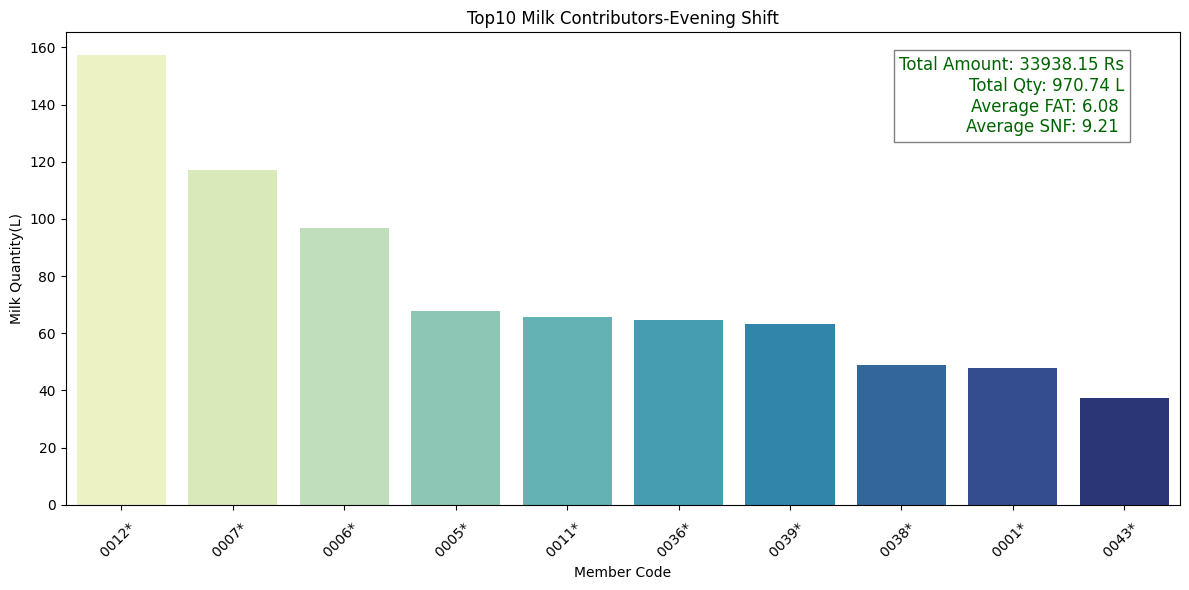

In [13]:
#Visualize top most milk contributer members
import matplotlib.pyplot as plt
import seaborn as sns

# Group by MEMBER CODE and sum Quantity
member_qty = data.groupby('MEMBER CODE')['Qty.'].sum().sort_values(ascending=False)

# Calculate total quantity
total_qty = member_qty.sum()
average_snf=np.mean(data['SNF'])
average_fat=np.mean(data['FAT'])
total_amount=np.sum(data['AMOUNT'])
# Plot top 10 contributors
plt.figure(figsize=(12, 6))
sns.barplot(
    x=member_qty.head(10).index,
    y=member_qty.head(10).values,
    hue=member_qty.head(10).index,
    palette='YlGnBu',
    legend=False
)
plt.title('Top10 Milk Contributors-Evening Shift')
plt.xlabel('Member Code')
plt.ylabel('Milk Quantity(L)')
plt.xticks(rotation=45)
# Annotate total quantity
plt.text(
    0.95, 0.95,
    f'Total Amount: {total_amount:.2f} Rs\nTotal Qty: {total_qty:.2f} L\nAverage FAT: {average_fat:.2f} \nAverage SNF: {average_snf:.2f} ',
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=12, color='darkgreen', bbox=dict(facecolor='white', edgecolor='gray')
)
plt.tight_layout()
plt.show()

In [14]:
#Analysing summary of statics
data.describe()

,FAT,SNF,RATE,Qty.,AMOUNT
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,6.075847,9.214126,36.194645,2.652295,92.727186
std,1.814307,0.405839,5.972136,1.140076,33.286399
min,3.290000,7.120000,26.290000,0.860000,31.770000
25%,4.640000,8.960000,31.517500,1.885000,72.910000
50%,5.540000,9.215000,34.425000,2.390000,86.465000
75%,7.410000,9.480000,40.265000,3.140000,101.882500
max,10.000000,10.000000,50.000000,6.960000,205.600000


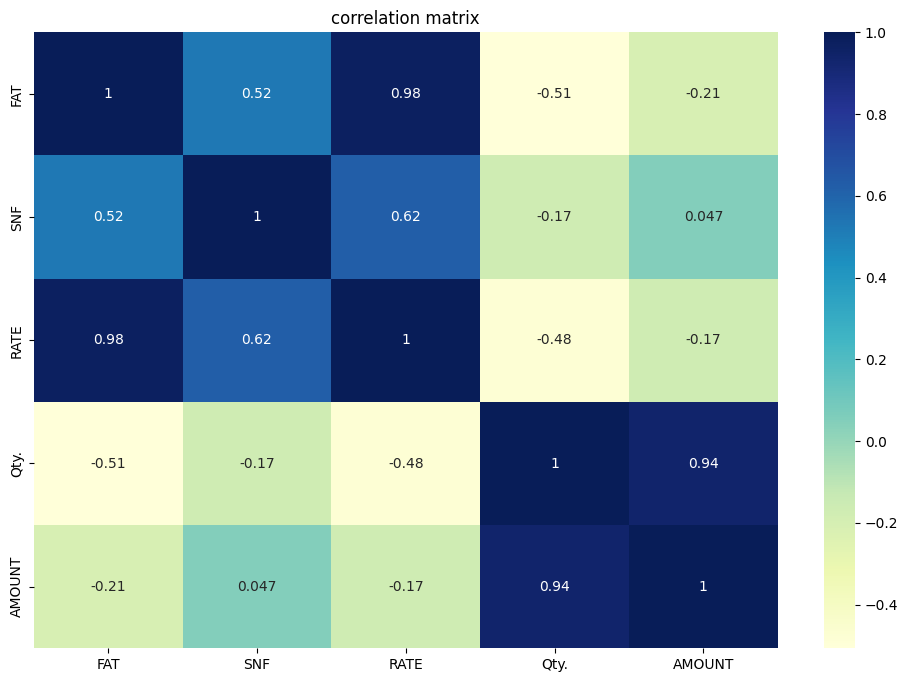

In [15]:
# Visualize correlation matrix
import numpy as np
#select only numeric values
numerical_data=data.select_dtypes(include=[np.number])

#calculate the correlation matrix
correlation=numerical_data.corr()

#Plot the correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(correlation, cmap='YlGnBu', annot=True)

plt.title('correlation matrix')
plt.show()

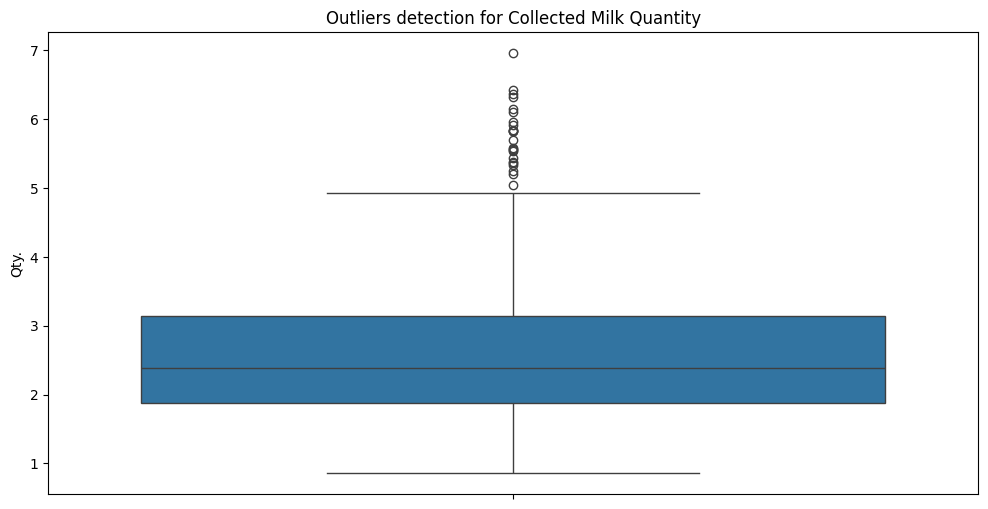

In [16]:
#Outliers Detectioin
if 'Qty.' in data.columns:
   # Proceed with plotting
   #Boxplot for outlier detection
    plt.figure(figsize=(12,6))
    sns.boxplot(data['Qty.'])
    plt.title('Outliers detection for Collected Milk Quantity')
    plt.show()
else:
    print("Column 'Qty.' not found.")
#Remove Outliers
q1=data['Qty.'].quantile(0.25)
q3=data['Qty.'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
cleaned_data=data[(data['Qty.']>=lower_bound)&(data['Qty.']<=upper_bound)]

In [17]:
##Split into Train-Test
from sklearn.model_selection import train_test_split
X=cleaned_data[['FAT', 'SNF','AMOUNT','RATE']]
Y=cleaned_data['Qty.']
print(cleaned_data.columns)
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2,random_state=42)

Index(['MEMBER CODE', 'FAT', 'SNF', 'RATE', 'Qty.', 'AMOUNT'], dtype='object')


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, Y_train)

# Predictions
Y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'MSE: {mse}')
print(f'R2 Score: {r2}')

MSE: 0.012190574237629545
R2 Score: 0.9788087888813947


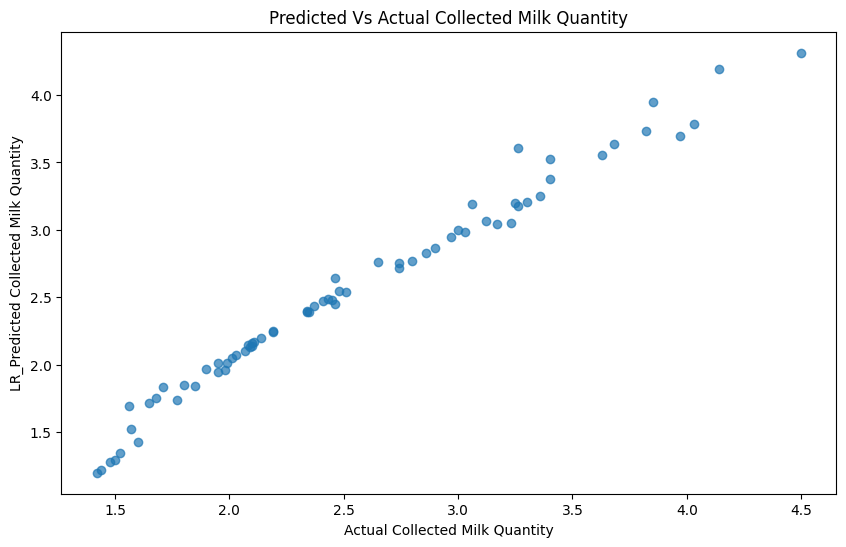

In [19]:
#Visualization Results
#scatter plot for Linear Regresson predictions vs actual
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred, alpha=0.7)
plt.xlabel('Actual Collected Milk Quantity')
plt.ylabel('LR_Predicted Collected Milk Quantity')
plt.title('Predicted Vs Actual Collected Milk Quantity')
plt.show()

Additional Evaluation Metrics

In [20]:
from xgboost import XGBRegressor
#Intialize the trained model
xgb_model=XGBRegressor(random_state=42)
xgb_model.fit(X_train, Y_train)

#Predictions
Y_pred_xgb=xgb_model.predict(X_test)

#Evaluate the model

mse_xgb=mean_squared_error(Y_test, Y_pred_xgb)
r2_xgb=r2_score(Y_test, Y_pred_xgb)
print(f'XGBoost MSE:{mse_xgb}')
print(f'XGBoost R^2:{r2_xgb}')

XGBoost MSE:0.007618402703868153
XGBoost R^2:0.9867567206484921


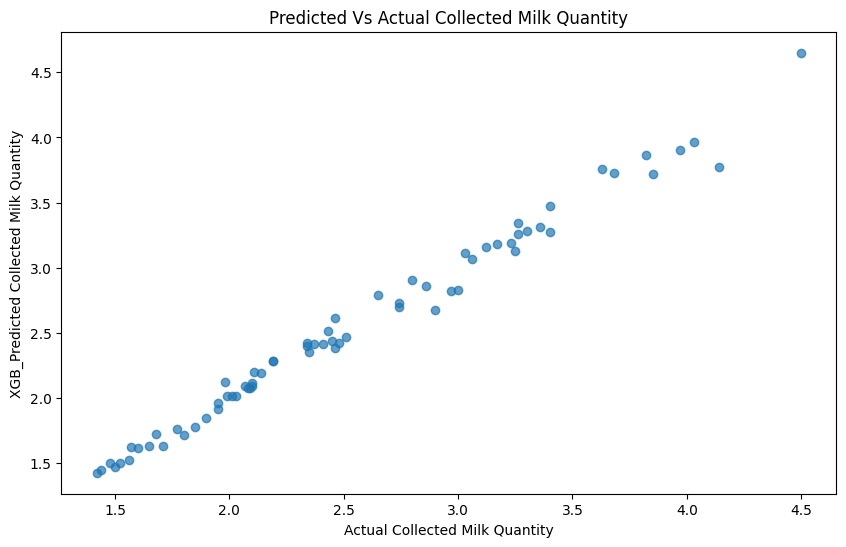

In [21]:
#scatter plot for XGBRegressor predictions vs actual
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred_xgb, alpha=0.7)
plt.xlabel('Actual Collected Milk Quantity')
plt.ylabel('XGB_Predicted Collected Milk Quantity')
plt.title('Predicted Vs Actual Collected Milk Quantity')
plt.show()

In [22]:
#Train a Random Forest Model
from sklearn.ensemble import RandomForestRegressor

#Intitialize and Train the model
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train, Y_train)

#Predictions
Y_pred_rf=rf_model.predict(X_test)

#Evaluate the model
mse_rf=mean_squared_error(Y_test, Y_pred_rf)
r2_rf=r2_score(Y_test, Y_pred_rf)
print(f'Random Forest MSE:{mse_rf}')
print(f'Random Forest R^2:{r2_rf}')

Random Forest MSE:0.004940935072463743
Random Forest R^2:0.9914110364119927


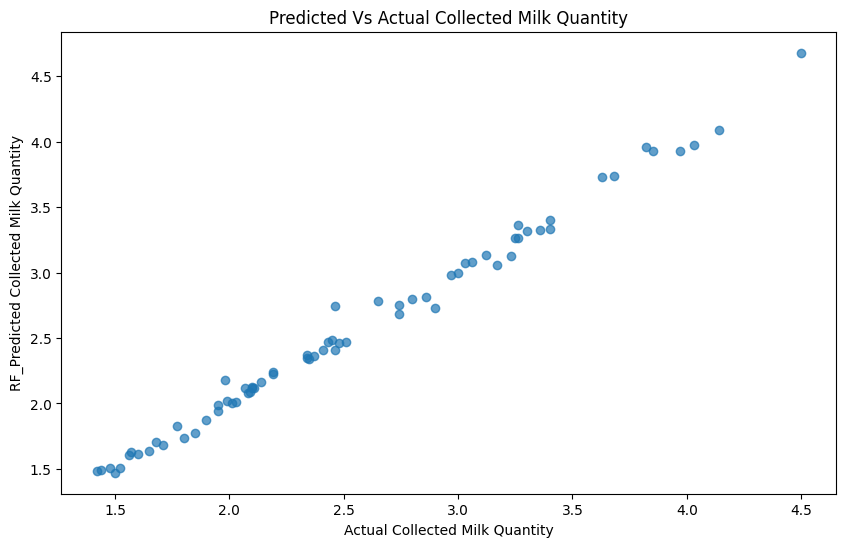

In [23]:
#scatter plot for Random Forest predictions vs actual
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred_rf, alpha=0.7)
plt.xlabel('Actual Collected Milk Quantity')
plt.ylabel('RF_Predicted Collected Milk Quantity')
plt.title('Predicted Vs Actual Collected Milk Quantity')
plt.show()

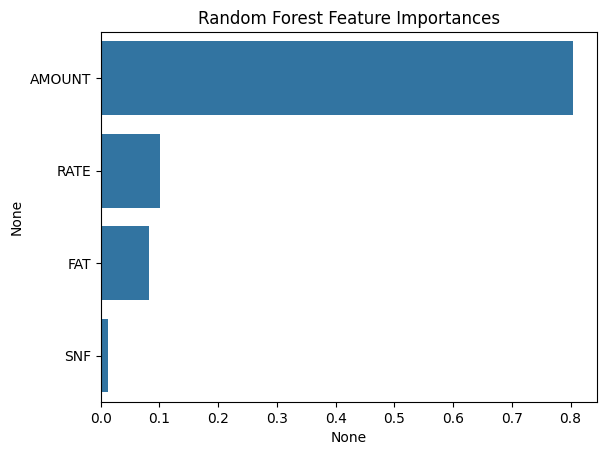

In [24]:
#Checking the importance of Feature to Predict by Random Forest Feature Importances
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
plt.title("Random Forest Feature Importances")
plt.show()

  Feature  Importance       Std
2  AMOUNT    1.471053  0.118059
3    RATE    0.187066  0.026185
0     FAT    0.089282  0.012368
1     SNF    0.002330  0.001122


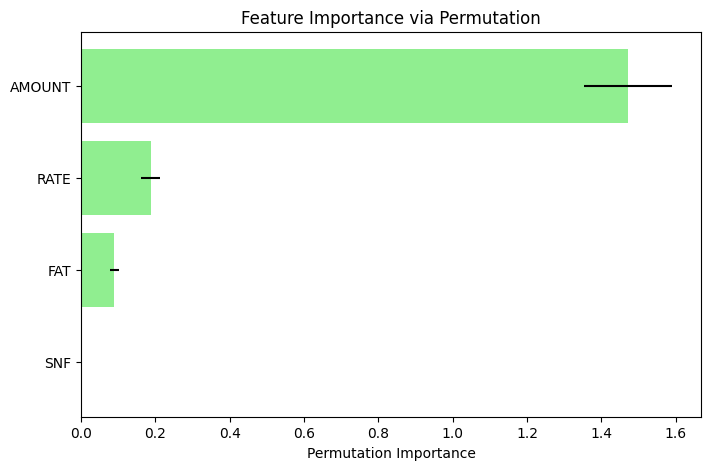

In [25]:
#Checking the importance of Feature to Predict by Permutation Importances
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Run permutation importance
result = permutation_importance(rf_model, X_test, Y_test, n_repeats=10, random_state=42)

# Organize results
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# Optional: Visualize
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], xerr=importance_df['Std'], color='lightgreen')
plt.xlabel("Permutation Importance")
plt.title("Feature Importance via Permutation")
plt.gca().invert_yaxis()
plt.show()

In [26]:

Total_Y_pred_rf=sum(Y_pred_rf)
print(Total_Y_pred_rf)

176.14379999999997


In [27]:
Total_Y_Test=sum(Y_test)
print(Total_Y_Test)

175.15


Insights:- Random Forest Model Best Fit here with the Milk Collection Project. 
Solutions: Need to merge Iot sensors with milk sensors(like milk analyser and Data Processing Unit) so that Random Forest can collect and analyse the data and predict the milk quantity share.

Random Forest is ideal for tabular, real-world data with mixed feature types and nonlinear relationships.

XGBoost is close behind, and may outperform Random Forest with careful hyperparameter tuning and feature scaling.

Linear Regression is useful as a baseline, but not sufficient for complex patterns in milk collection, also need feature scaling.
e.g., Feature Range: 
FAT(%)- ~3.5-8.0
SNF(%)- ~7.5-9.5
Qty(liters)- 1-50


Domain Knowledge:-

Question: Why Milk Collection Quantity Project shows Nonlinear Relationships?
Answer: 
Milk pricing and quantity are influenced by biological, economic, and operational factors that rarely behave in straight lines. Here's how key features interact in nonlinear ways:

1. FAT and SNF vs RATE (Price per Liter)
FAT (milk fat) and SNF (solids-not-fat) are quality indicators.

The RATE is often determined by a pricing formula that rewards higher FAT/SNF but with diminishing returns.
Price = (FAT × Rate per FAT) + (SNF × Rate per SNF)

Example of nonlinearity:

Going from 6% to 7% FAT might increase RATE by ₹2.

But going from 7% to 8% might only increase RATE by ₹1.5 — a nonlinear gain.

2. Threshold Effects
Also, Some dairy cooperatives use slab-based pricing:

E.g., if FAT > 6.5% and SNF > 8.5%, apply bonus RATE.

This creates step functions or discontinuities that Linear Regression can't model well.

3. Interaction Effects
The impact of FAT on RATE depends on SNF:

High FAT with low SNF might not fetch a premium.

But high FAT with high SNF could trigger a bonus.

These are multiplicative or conditional relationships, not additive.

4. Quantity vs RATE
Larger quantities might get bulk discounts or incentives.

But very high quantities might trigger logistic costs or quality dilution.

Again, this creates nonlinear curves in RATE vs QTY.



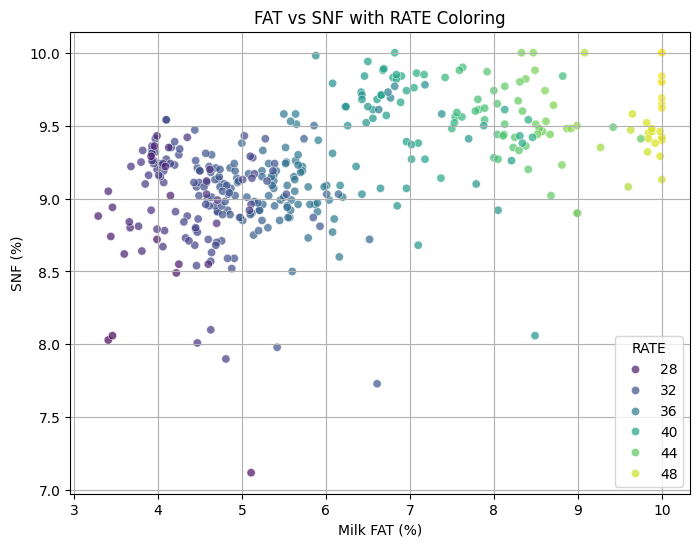

In [28]:
#Visual Example on Nonlinearity of Milk Collection Project 
#Imagine plotting RATE vs FAT:

#A Linear Regression would draw a straight line. But actual data might curve upward, flatten, sparsed, or jump at thresholds — which Random Forest and XGBoost can capture.


# Ploting FAT Vs SNF with rate Coloring
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='FAT', y='SNF', hue='RATE', palette='viridis', alpha=0.7)

plt.title('FAT vs SNF with RATE Coloring')
plt.xlabel('Milk FAT (%)')
plt.ylabel('SNF (%)')
plt.legend(title='RATE')
plt.grid(True)
plt.show()

In [29]:
#Collecting Morning Shift data sets
import pandas as pd
import glob
import os
#Handling Multi-CSV files of Daily Morning Shift Milk Collection to collet Raw Data Set
# Setting the path to CSV folder
MShift_csv_folder = 'D:\\Certified Program Data Science Associate\\9-Guided Project - Real World Data Science Application\\Savihaat Data Set\\M01-2022'  #  folder path

# Get all CSV file paths
MShift_csv_files = glob.glob(os.path.join(MShift_csv_folder, '*.csv'))

# Read and concatenate all CSVs
MShift_df_list = [pd.read_csv(file, skiprows=1) for file in MShift_csv_files]
MShift_Combined_df = pd.concat(MShift_df_list, ignore_index=False)
MShift_Data=pd.DataFrame(MShift_Combined_df)
print(MShift_Data)

         MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0            0032*       6.74     9.62     39.46      1.95       76.95
1            0018*       4.50     9.05     31.60      2.53       79.95
2            0012*       3.85     8.79     29.13      4.53      131.96
3            0011*       7.17     9.73     40.97      2.66      108.98
4            0008*       9.71     9.50     48.13      1.26       60.64
..               ...      ...      ...       ...       ...         ...
11      Average FAT:     5.70      NaN       NaN       NaN         NaN
12      Average SNF:     9.10      NaN       NaN       NaN         NaN
13     Average Rate:    32.48      NaN       NaN       NaN         NaN
14     Total  Qty  :    20.17      NaN       NaN       NaN         NaN
15  Total  Amount  :   655.04      NaN       NaN       NaN         NaN

[473 rows x 6 columns]


In [30]:
MShift_Data=MShift_Data.dropna()
print(MShift_Data.head(10))

  MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0     0032*       6.74     9.62     39.46      1.95       76.95
1     0018*       4.50     9.05     31.60      2.53       79.95
2     0012*       3.85     8.79     29.13      4.53      131.96
3     0011*       7.17     9.73     40.97      2.66      108.98
4     0008*       9.71     9.50     48.13      1.26       60.64
5     0005*       3.71     9.10     29.33      6.97      204.43
6     0010*       6.11     8.66     35.65      2.12       75.58
7     0036*       4.33     9.16     31.31      2.13       66.69
8     0037*       4.59     8.88     31.53      1.68       52.97
0     0032*       6.81     9.56     39.55      1.88       74.35


In [31]:
print(MShift_Data.tail(10))

  MEMBER CODE    FAT      SNF      RATE      Qty.      AMOUNT  
0     0032*       6.76     9.60     36.32      2.00       72.64
0     0032*       6.17     9.43     34.38      1.99       68.42
1     0017*       6.13     8.60     32.74      1.48       48.46
2     0011*       7.85     9.54     39.22      2.41       94.52
3     0029*       4.71     9.06     29.67      2.07       61.42
4     0033*       4.26     8.52     27.43      3.80      104.23
5     0018*       4.28     8.83     28.06      1.74       48.82
6     0012*       4.84     9.35     30.56      3.00       91.68
7     0022*       5.23     9.18     31.33      2.03       63.60
8     0008*       9.83     9.59     44.78      1.65       73.89


In [32]:
Missing_Values=MShift_Data.isnull().sum()
print(Missing_Values)

MEMBER CODE    0
  FAT          0
  SNF          0
  RATE         0
  Qty.         0
  AMOUNT       0
dtype: int64


In [33]:
#Deleting Spaces from Columns Titles
MShift_Data.columns = MShift_Data.columns.str.strip()
print(MShift_Data.columns)

Index(['MEMBER CODE', 'FAT', 'SNF', 'RATE', 'Qty.', 'AMOUNT'], dtype='object')


In [34]:
print(MShift_Data.head(10))

  MEMBER CODE   FAT   SNF   RATE  Qty.  AMOUNT
0     0032*    6.74  9.62  39.46  1.95   76.95
1     0018*    4.50  9.05  31.60  2.53   79.95
2     0012*    3.85  8.79  29.13  4.53  131.96
3     0011*    7.17  9.73  40.97  2.66  108.98
4     0008*    9.71  9.50  48.13  1.26   60.64
5     0005*    3.71  9.10  29.33  6.97  204.43
6     0010*    6.11  8.66  35.65  2.12   75.58
7     0036*    4.33  9.16  31.31  2.13   66.69
8     0037*    4.59  8.88  31.53  1.68   52.97
0     0032*    6.81  9.56  39.55  1.88   74.35


In [35]:
#Counting of Unique and Most Frequent Member Codes and estimating blanks
MShift_Data.describe(include='object')

,MEMBER CODE
count,256
unique,19
top,0032*
freq,29


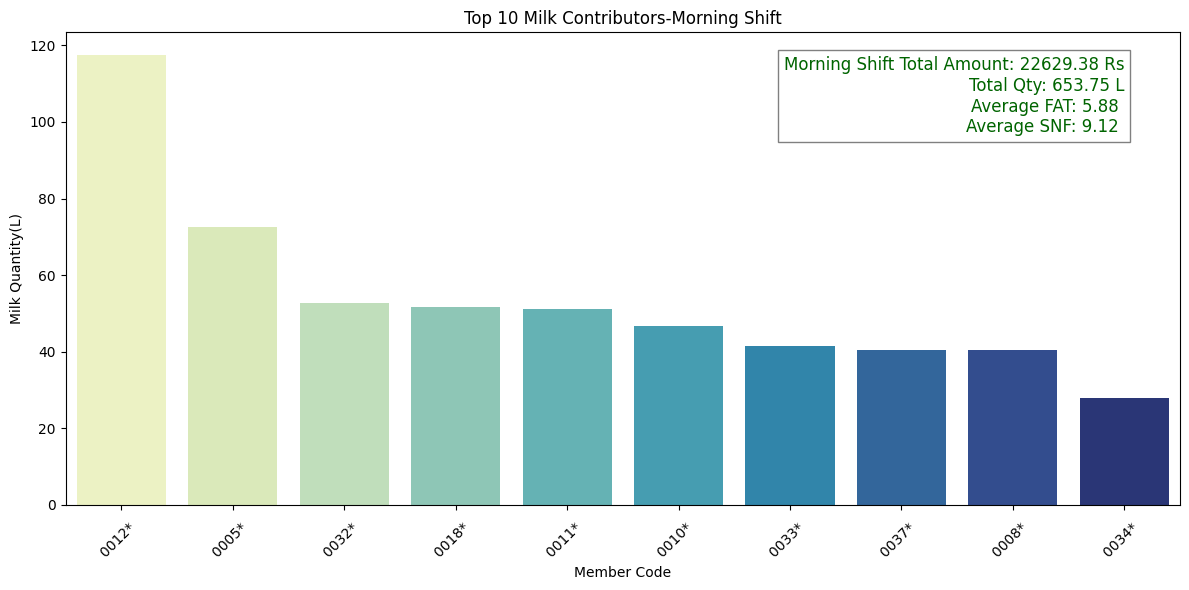

In [36]:
#Visualize top most milk contributer members in Morning Shift
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Group by MEMBER CODE and sum Quantity
MShift_member_qty = MShift_Data.groupby('MEMBER CODE')['Qty.'].sum().sort_values(ascending=False)

# Calculate total quantity
MShift_total_qty = MShift_member_qty.sum()
MShift_average_snf=np.mean(MShift_Data['SNF'])
MShift_average_fat=np.mean(MShift_Data['FAT'])
MShift_total_amount=np.sum(MShift_Data['AMOUNT'])
# Plot top 10 contributors
plt.figure(figsize=(12, 6))
sns.barplot(
    x=MShift_member_qty.head(10).index,
    y=MShift_member_qty.head(10).values,
    hue=MShift_member_qty.head(10).index,
    palette='YlGnBu',
    legend=False
)
plt.title('Top 10 Milk Contributors-Morning Shift')
plt.xlabel('Member Code')
plt.ylabel('Milk Quantity(L)')
plt.xticks(rotation=45)
# Annotate total quantity
plt.text(
    0.95, 0.95,
    f'Morning Shift Total Amount: {MShift_total_amount:.2f} Rs\nTotal Qty: {MShift_total_qty:.2f} L\nAverage FAT: {MShift_average_fat:.2f} \nAverage SNF: {MShift_average_snf:.2f} ',
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=12, color='darkgreen', bbox=dict(facecolor='white', edgecolor='gray')
)
plt.tight_layout()
plt.show()

In [37]:
from openpyxl.workbook import Workbook
# Save to Excel
excel_filename = "MorningShift_January 2022_data.xlsx"
MShift_Data.to_excel(excel_filename, index=False)
print(f"Excel file '{excel_filename}' created successfully.")


Excel file 'MorningShift_January 2022_data.xlsx' created successfully.


In [ ]:
#Dashboard Milk Collection app to deploy

import streamlit as st
import plotly.express as px
import pandas as pd

# Page config (should come first)
st.set_page_config(page_title="Milk Collection Dashboard", page_icon="🚚", layout="wide")

# Sidebar header
logo_col, name_col = st.columns([1, 6])

with logo_col:
    st.sidebar.image("D:\\SELP\\SaviHaat\\Savihaat Logo.png", width=60)

with name_col:
    st.sidebar.markdown("<h2 style='margin-bottom:0;color:green;'>SaviHaat (OPC) Pvt. Ltd.</h2>", unsafe_allow_html=True)
    st.sidebar.markdown("<p style='margin-top:0;color:blue;'>Empowering smarter milk collection🚚</p>", unsafe_allow_html=True)
    st.sidebar.markdown("<h4 style='text-align:center;color:green;'>Sample Project, Lomesh Kumar</h4>", unsafe_allow_html=True)
    st.sidebar.markdown("---")
    st.markdown("<h2 style='margin-bottom:0;color:blue;'>Milk Collection Dashboard</h2>", unsafe_allow_html=True)

# 📁 Upload dataset
uploaded_file = st.sidebar.file_uploader("Upload Milk Collection CSV", type=["csv"])

if uploaded_file:
    df = pd.read_csv(uploaded_file)

    # 🧹 Clean column names
    df.columns = df.columns.str.strip().str.upper()

    # 🗓️ Convert date column if present
    if "DATE" in df.columns:
        df["DATE"] = pd.to_datetime(df["DATE"])

    # 🔍 Optional filters
    if "SHIFT" in df.columns:
        selected_shift = st.sidebar.selectbox("Select Shift", df["SHIFT"].unique())
        df = df[df["SHIFT"] == selected_shift]


    # --- 🧮 KPIs ---
    total_amount = df["AMOUNT"].sum()
    total_volume = df["QTY."].sum()
    avg_fat = df["FAT"].mean()
    avg_snf = df["SNF"].mean()  # Changed from .max() to .mean() (optional)

    kpi1, kpi2, kpi3, kpi4 = st.columns(4)
    kpi1.metric(label="📁Total Amount", value=f"{total_amount:.0f} Rs")
    kpi2.metric(label="🥛Total Qty", value=f"{total_volume:.1f} L")
    kpi3.metric(label="📋Avg FAT", value=f"{avg_fat:.1f}")
    kpi4.metric(label="📋Avg SNF", value=f"{avg_snf:.1f}")

   # --- 📊 Top 10 Members Chart ---
# Group by MEMBER CODE and sum up the quantities
    top10 = (
        df.groupby("MEMBER CODE", as_index=False)["QTY."].sum().sort_values(by="QTY.", ascending=False).head(10)
        )

    

    fig = px.bar(
        top10,
        x="MEMBER CODE",
        y="QTY.",
        color="MEMBER CODE",
        text="QTY.",
        labels={"QTY.": "Milk Quantity (L)", "MEMBER CODE": "Farmer Code"},
        title="Top 10 Farmers by Milk Quantity",
    )
    fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
    fig.update_layout(showlegend=False)
    st.plotly_chart(fig, use_container_width=True)


else:
    st.info("📊Explore milk collection trends here.")

In [ ]:
from openpyxl.workbook import Workbook
# Save to Excel
excel_filename = "January 2022_data.xlsx"
January_df.to_excel(excel_filename, index=False)
print(f"Excel file '{excel_filename}' created successfully.")

In [41]:
#Predicting Quantity by fitting the model Random Forest
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Load data
EShift_Data = pd.read_csv('D:\\Certified Program Data Science Associate\\9-Guided Project - Real World Data Science Application\\Savihaat Data Set\\EveningShift_January 2022_data.csv')
MShift_Data = pd.read_csv('D:\\Certified Program Data Science Associate\\9-Guided Project - Real World Data Science Application\\Savihaat Data Set\\MorningShift_January 2022_data.csv')

# Combine shifts
def main():
    MShift_Data['Shift'] = 'Morning'
    EShift_Data['Shift'] = 'Evening'
    January_df = pd.concat([MShift_Data, EShift_Data], ignore_index=True)
    return January_df

January_df = main()
df = pd.DataFrame(January_df)

# Split into features and target
X = df[['FAT', 'SNF',]]
y = df['Qty.']

# Train model
model = RandomForestRegressor()
model.fit(X, y)

# Predict on new data
new_data = pd.DataFrame({
    'FAT': [6.12],
    'SNF': [9.5]
    
})

predicted = model.predict(new_data)

print("Predicted Milk Quantity:", predicted)
print("January Total Milk Quantity:", predicted*622)# milk quantity predition assuming last month milk entry


Predicted Milk Quantity: [2.167]
January Total Milk Quantity: [1347.874]
